<a href="https://colab.research.google.com/github/DataAnalyst-MiguelRodriguez/analysis-TomTom_Traffic_Index_y_OECD/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Eu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello se trabajó con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Se deberá **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.


In [ ]:
#Importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
En users: "city" con un 11.7% y "churn_date" con un 8.84%.
en usage: "date" con un 0.16%, "duration" con un 55.2% y "length" con un 44.74%.
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En users: hay que investigar para imputar o dejar como nulos.
- En usage: "date" se puede imputar o dejar como nulos.
            "duration" y "length" hay que investigar para imputar o dejar como nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
col_numericas_users = users[["user_id", "age"]]
col_numericas_users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no vale la pena analizarla, ya que es un codigo de identificacion, no podemos extraer informacion reelevante.
- La columna `age` se puede ver una minima de -999 lo cual es imposible en un rango de edad.

In [ ]:
# explorar columnas numéricas de usage
col_numericas_usage = usage[["id", "user_id", "duration", "length"]]
col_numericas_usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no vale la pena analizarlas, ya que es un codigo de identificacion, no podemos extraer informacion reelevante.
- Las columnas `duration` y `length` con tanta cantidad de nulos, no podemos decir a ciencia cierta que esta pasando, ya que debemos de llegar a la respuesta del porque hay tantos nulos, esto distorciona toda la informacion, no podemos sacar conclusiones.

In [ ]:
# explorar columnas categóricas de plans
columnas_categoricas_user = users[['city', 'plan']]
print(columnas_categoricas_user.describe())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` cuenta con valores nulos, cuenta con 7 diferentes paises de los cuales Bogota es el que mas veces se repite con 808.
- La columna `plan` no cuenta con valores nulos, solo contiene 2 categorias siendo "Basico" el que mas veces se repite con 2595.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no cuenta con valores nulos, cuenta con solo 2 categorias, siendo "text" la mas frecuente, repitiendose 22092 veces.


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- `age`  
- ¿Qué acción tomarías?
- Convertir la columna a numerico, luego reemplazar los sentinels por "NA" y luego sustituir por mediana.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors = "coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors = "coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, tenemos 4 años presentes "2022", "2023", "2024" y "2026", no hay datos de "2025" y "2026" contiene muy pocos datos.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, solo contiene datos del año 2024.
Basaremos el análisis en estas fechas.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? Si nos basamos en el año 2024, si, si existen años imposibles.
- ¿Qué harías con ellas? convertirlos en NA.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.


In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].mean()
users['age'] = np.where(users["age"]==-999, age_mediana, users["age"])

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       47.939922
std        17.769214
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
users["age"].describe() #Antes del cambio

count    4000.000000
mean       47.939922
std        17.769214
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
text_sentinels = ["?"]
users["city"] = users["city"].replace(text_sentinels, pd.NA)


# Verificar cambios
users["city"].isna().sum()


565

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [ ]:
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [ ]:
users["reg_date"].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.


In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Si el 99.9% de los nulos de `duration` se concentran en type == "text" y 99.9% de los nulos de `length` se concentran en type == "call" , eso es una señal muy fuerte de que no es aleatorio puro (MCAR), sino que depende de otra columna, es decir, MAR (Missing At Random, dependiente de otra variable observada).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamadas"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on= ["user_id"], how= "left")
user_profile.isna().sum()

user_id                     0
first_name                  0
last_name                   0
age                         0
city                      565
reg_date                   40
plan                        0
churn_date               3534
cant_mensajes               1
cant_llamadas               1
cant_minutos_llamadas       1
dtype: int64

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

In [ ]:
users["plan"].describe()

count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = users["age"].describe()
print(columnas_numericas)

count    4000.000000
mean       47.939922
std        17.769214
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Distribución porcentual del tipo de plan
columna_categorica = users["plan"].value_counts(normalize=True)
print(columna_categorica)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

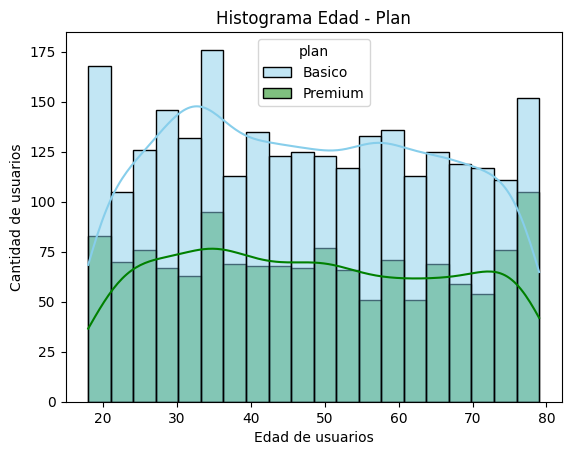

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data= user_profile, x= "age", hue= "plan", bins = 20, palette = ["skyblue", "green"], kde= True, edgecolor="black")
plt.xlabel("Edad de usuarios")
plt.ylabel("Cantidad de usuarios")
plt.title("Histograma Edad - Plan")
plt.show()


💡Insights:
- Distribución uniforme continua la variable edad no representa un sesgo marcado ni la clasica curva de campana (normal). La distribucion es practicamente uniforme a lo largo del espectro de edad.
- En todos los rangos de edad, el volumen total de usuarios del plan Basico supera sustancialmente al plan premium. La proporcion se mantiene relativamente constante: el plan Basico representa el volumen mayoritario de la base de usuarios activos.
- Com portamiento homogeneo por edad, esto indica que la edad no parece ser un factor determinante ni limitante para la eleccion entre el plan basico y el plan premium.

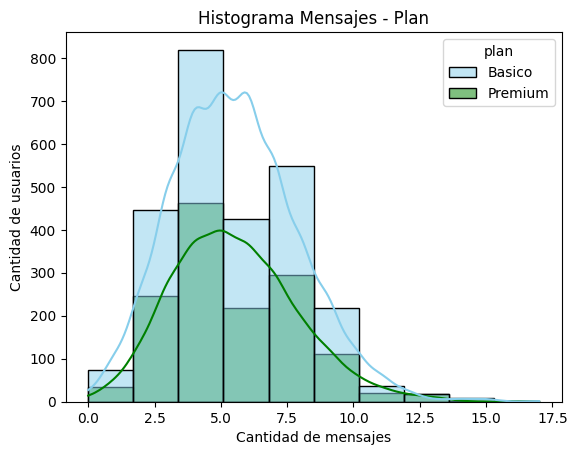

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x= "cant_mensajes", hue= "plan", bins = 10, palette = ["skyblue", "green"], kde= True, edgecolor="black")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.title("Histograma Mensajes - Plan")
plt.show()


💡Insights:
- El plan basico es el mas utilizado.
- Existe un comportamiento muy similiar en el uso de ambos planes, pero a distitnas escalas de volumen. No se observa que los usuarios premium envien significativamente mas mensajes que los basicos.
- Presenta una distribucion sesgada a la derecha.

Text(0.5, 1.0, 'Histograma llamadas - Plan')

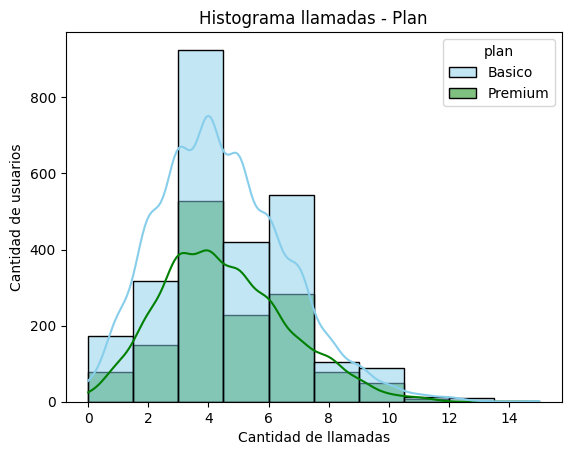

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x= "cant_llamadas", hue= "plan", bins= 10, palette= ["skyblue", "green"], kde= True, edgecolor= "black")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Histograma llamadas - Plan")

💡Insights:
- El plan mas utilizado es el plan basico. En la mayoria de las barras se observa una mayor cantidad total de usuarios ene l plan basico en comparacion con el plan premium.
- El comportamiento de consumo es practicamente identico en ambos planes.La mayor parte de los usuarios, independientemente de si pagan el plan basico o el premium, realiza entre 3 y 8 llamadas.
- Es una distribucion sesgada a la derecha. La mayor concentracion de los datos se situa en los valores bajos y medios, mientras que la cola de la distribucion se alarga hacia la derecha, disminuyendo progresivamente la frecuencia de usuarios.

Text(0.5, 1.0, 'Histograma: Cantidad de minutos por llamada - Plan')

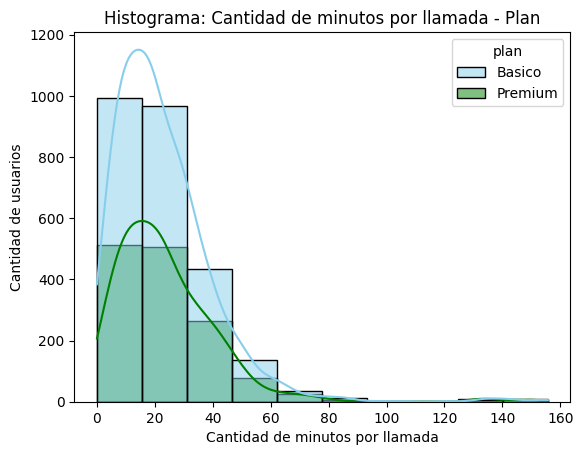

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x= "cant_minutos_llamadas", hue= "plan", bins= 10, palette= ["skyblue", "green"], kde= True, edgecolor= "black")
plt.xlabel("Cantidad de minutos por llamada")
plt.ylabel("Cantidad de usuarios")
plt.title("Histograma: Cantidad de minutos por llamada - Plan")

💡Insights:
- El plan basico es el dominante en volumen de usuarios. La altura total del area azul supera holgadamente a la del plan premium, registrando picos de casi 1000 usuarios por barra en las llamadas mas cortas.
- El comportamiento de uso es analogo enambos segmentos. A partir de los 30 min la frecuencia cae drasticamente para ambos tipos de usuarios, demostrando que tener una suscripcion premium no impulsa a los usuarios a realizar llamadas significativamente mas largas.
- Es una distribucion sesgada a la derecha. El grueso de la frecuencia esta m asivamente concentrado cerca del origen y decae de forma acelerada, dejando una larga cola a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

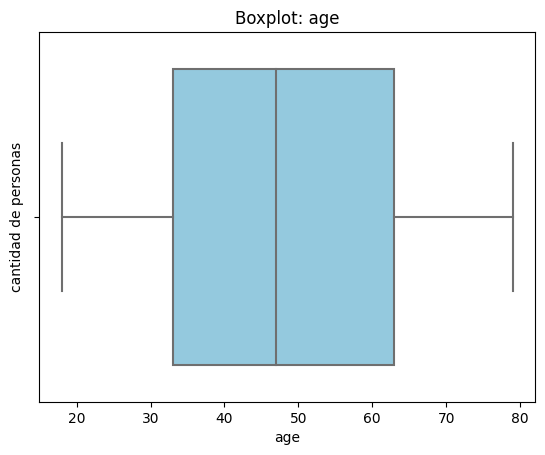

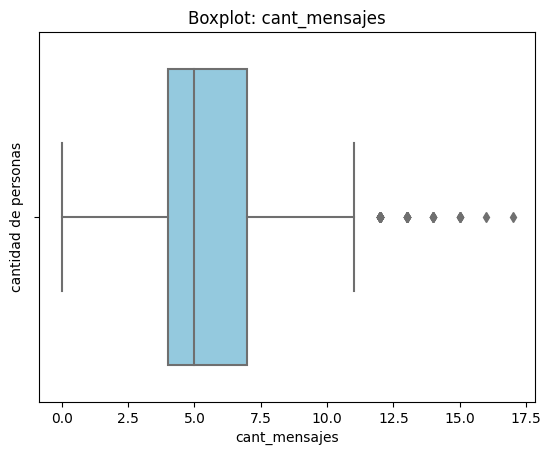

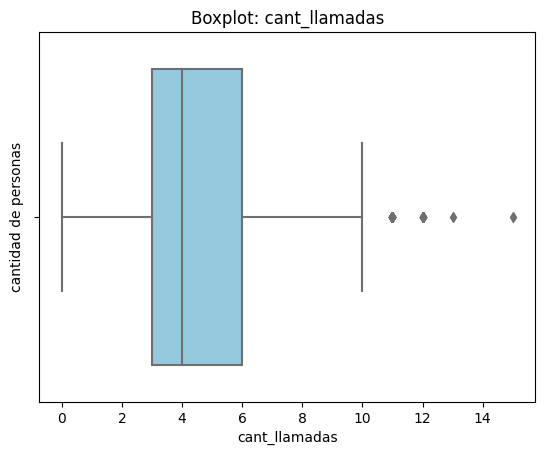

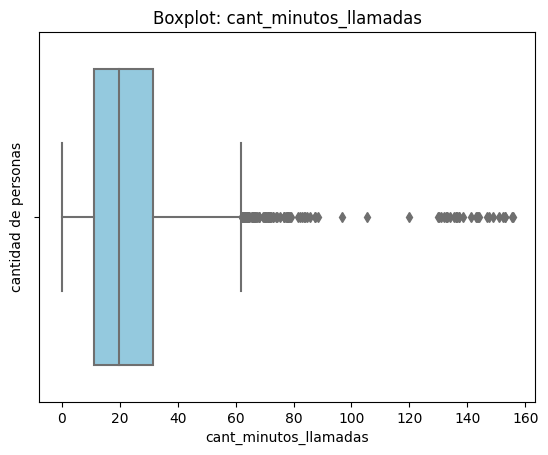

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color= "skyblue")
    plt.title(f'Boxplot: {col}')
    plt.ylabel("cantidad de personas")
    plt.show()

💡Insights:
- Age: No presenta outliers.
- cant_mensajes: Si presenta outliers.
- cant_llamadas: Si presenta outliers.
- cant_minutos_llamada: Si presenta outliers.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamadas"]
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(col)
    print(f'Limite inferior: {lower}')
    print(f'Limite superior: {upper}')
    print()

cant_mensajes
Limite inferior: -0.5
Limite superior: 11.5

cant_llamadas
Limite inferior: -1.5
Limite superior: 10.5

cant_minutos_llamadas
Limite inferior: -19.322500000000005
Limite superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: se deben mantener intactos, ya que estos modelos no se ven alterados por la escala de los valores atípicos.
- cant_llamadas: se deben mantener intactos, ya que estos modelos no se ven alterados por la escala de los valores atípicos.
- cant_minutos_llamada: se deben mantener intactos, ya que estos modelos no se ven alterados por la escala de los valores atípicos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

def clasificacion_uso (row):
    mensajes = row["cant_mensajes"]
    llamadas = row["cant_llamadas"]
    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error de datos"
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    if llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificacion_uso, axis= 1)

In [ ]:
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad (row):
    edad = row["age"]
    if edad < 30:
        return "Joven"
    if edad < 60:
        return "Adulto"
    else:
        return "Adulto mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis= 1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


In [ ]:
print(user_profile["grupo_uso"].value_counts())

Uso medio         2943
Bajo uso           778
Alto uso           278
Error de datos       1
Name: grupo_uso, dtype: int64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

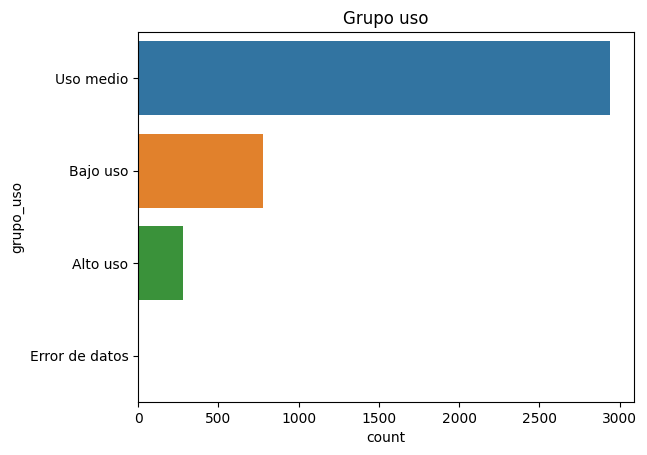

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data= user_profile, y= "grupo_uso", order= user_profile["grupo_uso"].value_counts().index)
plt.title("Grupo uso")
plt.show()

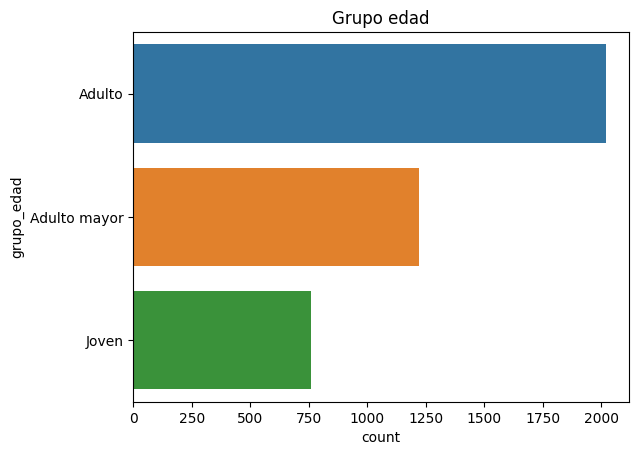

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data= user_profile, y= "grupo_edad", order= user_profile["grupo_edad"].value_counts().index)
plt.title("Grupo edad")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Al dar el primer analisis de los dataframe, pudimos notar la cantidad de faltantes. Habia dos columnas en especifico del dataframe de usage que contenian arriba del 40% de faltantes (length y duration). Pero continuando con el analisis pudimos ver que era lo que estaba pasando y tenian que ver con otra variable.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Hicimos dos segmentaciones, segun su uso y su edad. Donde podemos ver claramente que para la categoria de uso predomina el "uso medio" y para edad, predomina el "Adulto".


- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
"Adultos de uso medio" es el motor financiero actual del negocio. Toda estrategia de retencion debe priorizar este grupo para proteger la base de ingresos principal.
El segmento de mayor oportunidad de monetizacion seria "Alto uso" / Jovenes y adultos. Aunque el grupo "Alto uso" representa una fraccion menor en volumen, suele ser el grupo que contrata planes mas costosos o genera cobros adicionales por exceso de uso.
Si los usuarios de "Uso medio" estan cerca de su limite, representa la mejor oporunidad comercial para pasarlos a planes superirores.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se encontraron varios patrones de uso extremo en llamadas, mensajes y minutos por llamadas. Pero esto fuera de ser errores, podriamos clasificarlos como VIP, ya que son valores extremos reales.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Crear Nuevos Planes Segmentados por Perfil de Edad y Uso
Plan "Conectados" (Diseñado para Jóvenes):

Enfoque: Alta demanda de datos móviles y baja necesidad de llamadas tradicionales o SMS.

Propuesta: Redes sociales ilimitadas o mayor bolsa de GB a cambio de cuotas reducidas de minutos y mensajes tradicionales.

Plan "Familiar / Negocios" (Diseñado para Alto Uso):

Enfoque: Fidelizar y capturar al segmento de Alto Uso (los clientes que realizan llamadas largas de hasta 150 minutos o envíos intensivos).

Propuesta: Tarifas planas de minutos sin penalización por llamadas de larga duración o planes multilínea donde se pueda compartir la bolsa de minutos/datos entre varios miembros.

Plan "Esencial / Dorado" (Diseñado para Adultos Mayores):

Enfoque: Un segmento representativo con patrones de uso moderado o enfocado principalmente en llamadas directas.

Propuesta: Paquete simplificado centrado en voz y mensajería instantánea (como WhatsApp) a un precio altamente competitivo y sin cobros sorpresa.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Problemas estadisticos y valores atipicos.
      - Limites inferiores matematicamente irreales.
      - Valores extremos por arriba del limite superior.
- Inconsistencias de negocio y segmentacion.
      - Desalineacion entre consumo y planes contratados.
      - Regsitros anomalos de categoria.


🔍 **Segmentos por Edad**
- Adultos (segmento dominante)
- Adultos mayores (segmento secundario)
- Jovenes (segmento minoritario)


📊 **Segmentos por Nivel de Uso**
- Uso medio (masa critica)
- Bajo uso (segmento secundario)
- Alto uso (segmento minoritario)
- Error de datos: Registra una cantidad insignificante de observaciones (1), pero señala la presencia de inconsistencias o registros que deben filtrarse durante la limpieza.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Reestructurar la oferta comercial hacia Datos: Eliminar el enfoque en llamadas y SMS ilimitados —donde el consumo es casi idéntico entre planes— y centrar la diferenciación del plan Premium en cuotas de gigabytes, velocidad y beneficios de streaming.
- Lanzar un "Plan" para la masa crítica (Uso Medio / Adultos): Diseñar un plan intermedio optimizado para el 75% de la base de usuarios, incentivando un upselling accesible desde el plan Básico para incrementar los ingresos recurrentes sin forzar saltos tarifarios drásticos.
- Personalizar por edad y controlar a los Heavy Users: Implementar planes por perfil demográfico (alta bolsa de datos para Jóvenes y paquetes simplificados para Adultos Mayores), aplicando políticas de uso justo (Capping) al segmento de Alto Uso para proteger los márgenes de la empresa.